

### 1. Data Preprocessing & Splitting

This step handles the sequential split and applies the `StandardScaler` (fitting only on the training set to prevent look-ahead bias).

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../golden_dataset.csv')

In [7]:
df['excercise'] = df['excercise'].map({"bench_press": 0, "arm_curl": 1})

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is loaded into 'df'
# Note: Ensure your target column doesn't have a leading space,
# e.g., use df.rename(columns={" exercise": "exercise"}, inplace=True)

features = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
target = "excercise"

# 1. Sequential Train-Test Split (First 80% train, last 20% test)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

# 2. Fit scaler ONLY on TRAIN, then transform both
scaler = StandardScaler()
train_df.loc[:, features] = scaler.fit_transform(train_df[features])
test_df.loc[:, features] = scaler.transform(test_df[features])

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")

Train rows: 254208 | Test rows: 63553


In [23]:
train_df

,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,excercise
0,0.732904,-6.583941,-9.237241,0.825259,0.202146,1.361768,0
1,4.747473,-4.025917,-11.238393,3.490886,0.175850,2.353053,0
2,3.667257,-4.252154,-10.285298,-0.653285,0.112027,2.683306,0
3,4.931451,-6.354228,-10.087550,-2.178275,0.906664,5.638496,0
4,4.009720,-4.346402,-10.392964,-0.050681,1.979325,7.789081,0
...,...,...,...,...,...,...,...
254203,-0.193549,0.133905,0.137441,0.004243,0.005316,0.004405,0
254204,-0.207868,0.090786,0.135242,0.004509,0.005389,0.004164,0
254205,-0.197129,0.119532,0.146235,0.004868,0.005537,0.003961,0
254206,-0.200708,0.131509,0.166022,0.004894,0.005351,0.003941,0


### 2. Sliding Window Dataset

This custom PyTorch `Dataset` takes your continuous single dataframe and chops it into overlapping windows. For the window label, it uses the most frequent class (`mode`) occurring within that specific window timeframe.

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader

class IMUDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, window_size, step_size):
        self.features = df[feature_cols].values
        self.labels = df[target_col].values
        self.window_size = window_size
        self.step_size = step_size

        self.samples = []

        # Generate sliding windows
        for start_idx in range(0, len(df) - window_size + 1, step_size):
            end_idx = start_idx + window_size
            window_features = self.features[start_idx:end_idx]
            window_labels = self.labels[start_idx:end_idx]

            # The label for the window is the most frequent activity in that window
            label = np.bincount(window_labels).argmax()

            self.samples.append((window_features, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        # x shape: (window_size, num_features)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# 3. Build Datasets
window_size = 100  # Adjust based on your sensor's sampling rate
step_size = 50     # 50% overlap

train_dataset = IMUDataset(train_df, features, target, window_size, step_size)
test_dataset  = IMUDataset(test_df, features, target, window_size, step_size)

# 4. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
len(train_dataset.samples)

5083

### 3. The CNN-LSTM Model

The architecture uses a 1D Convolutional layer to extract local spatial patterns from the 6 sensor channels, followed by an LSTM to track the temporal dynamics of the exercise over the window's duration.

In [30]:
import torch.nn as nn
import torch.nn.functional as F

class CNNLSTM(nn.Module):
    def __init__(self, input_size=6, num_classes=2, hidden_size=64, num_layers=1):
        super(CNNLSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out

### 4. Training and Evaluation Loop

Finally, instantiate the model and train it using standard Cross-Entropy Loss, which handles binary classification seamlessly when `num_classes=2`.

In [31]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = CNNLSTM(input_size=len(features), num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}\n")

for name, param in model.named_parameters():
     print(f"{name}: {param.numel()} parameters")

Total parameters: 142786

conv1.weight: 1920 parameters
conv1.bias: 64 parameters
bn1.weight: 64 parameters
bn1.bias: 64 parameters
conv2.weight: 40960 parameters
conv2.bias: 128 parameters
bn2.weight: 128 parameters
bn2.bias: 128 parameters
conv3.weight: 49152 parameters
conv3.bias: 128 parameters
bn3.weight: 128 parameters
bn3.bias: 128 parameters
lstm.weight_ih_l0: 32768 parameters
lstm.weight_hh_l0: 16384 parameters
lstm.bias_ih_l0: 256 parameters
lstm.bias_hh_l0: 256 parameters
fc.weight: 128 parameters
fc.bias: 2 parameters


In [34]:


num_epochs = 50

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_loss = train_loss / train_total
    epoch_acc = train_correct / train_total

   
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

Epoch 01/50 | Train Loss: 0.1032 | Train Acc: 0.9569
Epoch 02/50 | Train Loss: 0.1008 | Train Acc: 0.9587
Epoch 03/50 | Train Loss: 0.1136 | Train Acc: 0.9530
Epoch 04/50 | Train Loss: 0.0972 | Train Acc: 0.9561
Epoch 05/50 | Train Loss: 0.0938 | Train Acc: 0.9603
Epoch 06/50 | Train Loss: 0.0934 | Train Acc: 0.9587
Epoch 07/50 | Train Loss: 0.0881 | Train Acc: 0.9644
Epoch 08/50 | Train Loss: 0.0870 | Train Acc: 0.9640
Epoch 09/50 | Train Loss: 0.0941 | Train Acc: 0.9607
Epoch 10/50 | Train Loss: 0.0909 | Train Acc: 0.9646
Epoch 11/50 | Train Loss: 0.0887 | Train Acc: 0.9632
Epoch 12/50 | Train Loss: 0.0878 | Train Acc: 0.9634
Epoch 13/50 | Train Loss: 0.0900 | Train Acc: 0.9640
Epoch 14/50 | Train Loss: 0.0687 | Train Acc: 0.9730
Epoch 15/50 | Train Loss: 0.0775 | Train Acc: 0.9679
Epoch 16/50 | Train Loss: 0.0698 | Train Acc: 0.9730
Epoch 17/50 | Train Loss: 0.0637 | Train Acc: 0.9746
Epoch 18/50 | Train Loss: 0.0604 | Train Acc: 0.9760
Epoch 19/50 | Train Loss: 0.0600 | Train Acc: 

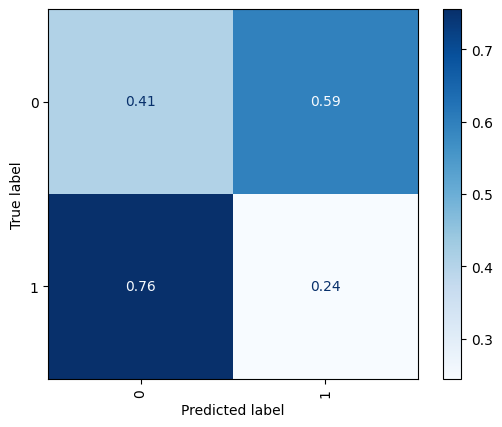

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        outputs = model(X)
        preds = outputs.argmax(dim=1)

        y_true.extend(y.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.show()